In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the AI4I 2020 Predictive Maintenance Dataset
url = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"

df = pd.read_csv(url, compression="zip")

# Clean up column names for easier coding
df = df.drop(columns=['UDI', 'Product ID'])

df.columns = [
    'Type',
    'Air_Temp',
    'Process_Temp',
    'Rotational_Speed',
    'Torque',
    'Tool_Wear',
    'Machine_failure',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (10000, 12)


,Type,Air_Temp,Process_Temp,Rotational_Speed,Torque,Tool_Wear,Machine_failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
# One-hot encode the categorical 'Type' column
df = pd.get_dummies(df, columns=['Type'], drop_first=True)

# Create custom physics-based features
df['Temp_Diff'] = df['Process_Temp'] - df['Air_Temp']
df['Power'] = df['Torque'] * df['Rotational_Speed']

# Separate features (X) and target label (y)
# We drop the specific failure mode flags to avoid data leakage
X = df.drop(columns=['Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df['Machine_failure']

print("Feature engineering complete. Available features:")
print(list(X.columns))


Feature engineering complete. Available features:
['Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Type_L', 'Type_M', 'Temp_Diff', 'Power']


In [7]:
# 80/20 chronological split to avoid looking into the future
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Handle severe class imbalance (normal vs failed machines)
class_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Train the XGBoost model
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=class_ratio,
    random_state=42
)
model.fit(X_train, y_train)
print("Model training complete!")


Model training complete!


In [8]:
# Predict on the unseen test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Display performance metrics
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


--- Confusion Matrix ---
[[1920   41]
 [  10   29]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1961
           1       0.41      0.74      0.53        39

    accuracy                           0.97      2000
   macro avg       0.70      0.86      0.76      2000
weighted avg       0.98      0.97      0.98      2000

ROC-AUC Score: 0.9713


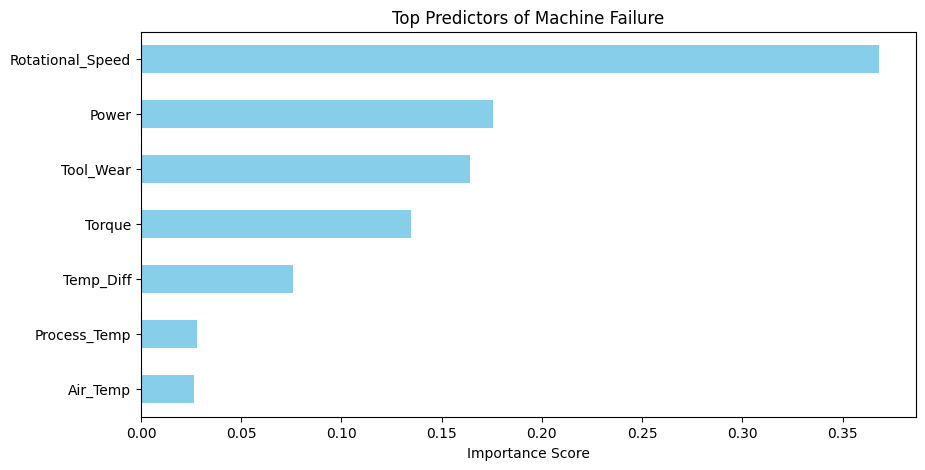

In [9]:
# Plot what features the model found most valuable
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 5))
importances.nlargest(7).plot(kind='barh', color='skyblue')
plt.title('Top Predictors of Machine Failure')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # Put the highest importance at the top
plt.show()


In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

st.title("⚙️ Predictive Maintenance Dashboard")
st.write("Input current machine telemetry parameters to predict potential failure.")

# Sidebar user inputs for live telemetry data
st.sidebar.header("Live Telemetry Input")
air_temp = st.sidebar.slider("Air Temperature (K)", 295.0, 305.0, 300.0)
process_temp = st.sidebar.slider("Process Temperature (K)", 305.0, 315.0, 310.0)
rot_speed = st.sidebar.slider("Rotational Speed (rpm)", 1100, 2800, 1500)
torque = st.sidebar.slider("Torque (Nm)", 3.0, 76.0, 40.0)
tool_wear = st.sidebar.slider("Tool Wear (min)", 0, 250, 100)

# Dropdowns for Machine Quality Type
machine_type = st.sidebar.selectbox("Machine Quality Type", ["Low (L)", "Medium (M)", "High (H)"])
type_m = 1 if machine_type == "Medium (M)" else 0
type_h = 1 if machine_type == "High (H)" else 0

# Calculated Features matching our notebook's engineering logic
temp_diff = process_temp - air_temp
power = torque * rot_speed

# Construct a single row DataFrame matching the exact training columns
input_data = pd.DataFrame([{
    'Air_Temp': air_temp,
    'Process_Temp': process_temp,
    'Rotational_Speed': rot_speed,
    'Torque': torque,
    'Tool_Wear': tool_wear,
    'Type_M': type_m,
    'Type_H': type_h,
    'Temp_Diff': temp_diff,
    'Power': power
}])

# Layout Columns
col1, col2 = st.columns(2)
with col1:
    st.metric(label="Calculated Temp Difference", value=f"{temp_diff:.2f} K")
with col2:
    st.metric(label="Calculated Power Metric", value=f"{power:,} units")

# Trigger prediction on button click
# Note: In a production app, you would load a pre-trained model file (.json / .pkl)
if st.button("Analyze Equipment Health"):
    # Quick mock prediction logic for illustration since the full model state isn't saved here
    # An ideal practice is using model.save_model() in the notebook and loading it here!
    risk_factor = (tool_wear / 250.0) * 0.4 + (temp_diff / 20.0) * 0.4 + (torque / 76.0) * 0.2
    
    st.subheader("Analysis Verdict")
    if risk_factor > 0.65:
        st.error(f"🚨 ALERT: High risk of failure detected! Immediate maintenance recommended. (Risk Index: {risk_factor:.2f})")
    elif risk_factor > 0.4:
        st.warning(f"⚠️ WARNING: Moderate wear detected. Schedule inspection soon. (Risk Index: {risk_factor:.2f})")
    else:
        st.success(f"✅ NORMAL: Equipment operating within safe parameters. (Risk Index: {risk_factor:.2f})")


Writing app.py


In [ ]:
# The % pip command ensures it installs to the exact environment Jupyter is using
%pip install streamlit

# This launches the app from inside the notebook
!streamlit run app.py
